In [3]:
import pandas as pd
import random

import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix,classification_report,r2_score



In [2]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Ensemble Models
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    HistGradientBoostingClassifier
)
from xgboost import XGBClassifier

# LightGBM
from lightgbm import LGBMClassifier

# CatBoost
from catboost import CatBoostClassifier


In [1]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,)

In [5]:
from catboost import CatBoostClassifier

In [4]:
df=pd.read_csv(r"D:\ML project\US traffic\data\us_congestion_2016_2022_sample_2m.csv")

In [5]:
df

,ID,Severity,Start_Lat,Start_Lng,StartTime,EndTime,Distance(mi),DelayFromTypicalTraffic(mins),DelayFromFreeFlowSpeed(mins),Congestion_Speed,...,Temperature(F),WindChill(F),Humidity(%),Pressure(in),Visibility(mi),WindDir,WindSpeed(mph),Precipitation(in),Weather_Event,Weather_Conditions
0,C-14344128,2,39.191032,-120.819740,2016-12-20T19:19:00.000-05:00,2016-12-20T19:33:47.000-05:00,1.40,2.58,2.60,Moderate,...,54.0,NaN,30.0,30.15,10.0,North,3.5,NaN,NaN,Clear
1,C-32285069,0,41.736015,-87.721565,2018-11-16T17:18:00.000-05:00,2018-11-16T18:08:28.000-05:00,0.73,0.42,1.00,Slow,...,39.0,31.8,70.0,30.06,10.0,West,11.5,NaN,NaN,Overcast
2,C-14213642,0,32.519043,-93.741096,2021-02-18T20:32:00.000-05:00,2021-02-18T21:21:32.000-05:00,1.80,1.00,2.00,Moderate,...,30.0,30.0,79.0,30.20,10.0,WNW,3.0,0.00,NaN,Fair
3,C-29674072,0,40.730564,-74.001709,2020-11-13T08:06:00.000-05:00,2020-11-13T08:48:22.000-05:00,1.42,1.00,2.00,Slow,...,48.0,48.0,93.0,29.92,1.0,VAR,3.0,0.04,NaN,Light Rain
4,C-24044478,1,33.758331,-118.238533,2017-08-24T09:54:00.000-04:00,2017-08-24T11:13:19.000-04:00,2.60,4.90,6.92,Slow,...,66.9,NaN,79.0,29.89,9.0,Calm,NaN,NaN,NaN,Overcast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,C-26612807,2,36.987309,-121.487808,2019-06-28T18:00:00.000-04:00,2019-06-28T19:01:26.000-04:00,7.02,12.00,18.00,Moderate,...,75.0,75.0,38.0,29.74,10.0,NE,5.0,0.00,NaN,Fair
1999996,C-9975445,2,34.051392,-118.260674,2018-10-19T16:37:00.000-04:00,2018-10-19T17:58:47.000-04:00,5.53,2.30,4.18,Moderate,...,88.0,NaN,16.0,29.94,10.0,North,NaN,NaN,NaN,Clear
1999997,C-26223902,1,41.944290,-70.981705,2019-11-11T23:21:00.000-05:00,2019-11-12T00:04:15.000-05:00,1.01,32.00,32.00,Slow,...,51.0,51.0,77.0,29.85,10.0,CALM,0.0,0.00,NaN,Cloudy
1999998,C-1229875,2,37.968166,-121.971741,2018-02-02T09:06:00.000-05:00,2018-02-02T09:46:43.000-05:00,1.64,15.65,15.88,Slow,...,48.0,NaN,80.0,30.12,10.0,Calm,NaN,NaN,NaN,Clear


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 30 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   ID                             object 
 1   Severity                       int64  
 2   Start_Lat                      float64
 3   Start_Lng                      float64
 4   StartTime                      object 
 5   EndTime                        object 
 6   Distance(mi)                   float64
 7   DelayFromTypicalTraffic(mins)  float64
 8   DelayFromFreeFlowSpeed(mins)   float64
 9   Congestion_Speed               object 
 10  Description                    object 
 11  Street                         object 
 12  City                           object 
 13  County                         object 
 14  State                          object 
 15  Country                        object 
 16  ZipCode                        object 
 17  LocalTimeZone                  object 
 18  We

In [9]:
df.isna().sum()

ID                                     0
Severity                               0
Start_Lat                              0
Start_Lng                              0
StartTime                           1823
EndTime                             1823
Distance(mi)                           0
DelayFromTypicalTraffic(mins)          0
DelayFromFreeFlowSpeed(mins)           0
Congestion_Speed                       0
Description                            0
Street                                98
City                                 118
County                                 0
State                                  0
Country                                0
ZipCode                             1351
LocalTimeZone                       1823
WeatherStation_AirportCode          3326
WeatherTimeStamp                   32128
Temperature(F)                     43957
WindChill(F)                      759205
Humidity(%)                        46167
Pressure(in)                       41123
Visibility(mi)  

In [10]:
df1=df.drop(columns=['ID','Description','ZipCode','Country','LocalTimeZone', 'WeatherStation_AirportCode', 'WeatherTimeStamp',
        'WindChill(F)', 'Pressure(in)', 'WindDir', 'WindSpeed(mph)', 'Precipitation(in)'])

In [11]:
df1

,Severity,Start_Lat,Start_Lng,StartTime,EndTime,Distance(mi),DelayFromTypicalTraffic(mins),DelayFromFreeFlowSpeed(mins),Congestion_Speed,Street,City,County,State,Temperature(F),Humidity(%),Visibility(mi),Weather_Event,Weather_Conditions
0,2,39.191032,-120.819740,2016-12-20T19:19:00.000-05:00,2016-12-20T19:33:47.000-05:00,1.40,2.58,2.60,Moderate,I-80 W,Dutch Flat,Placer,CA,54.0,30.0,10.0,NaN,Clear
1,0,41.736015,-87.721565,2018-11-16T17:18:00.000-05:00,2018-11-16T18:08:28.000-05:00,0.73,0.42,1.00,Slow,S Pulaski Rd,Chicago,Cook,IL,39.0,70.0,10.0,NaN,Overcast
2,0,32.519043,-93.741096,2021-02-18T20:32:00.000-05:00,2021-02-18T21:21:32.000-05:00,1.80,1.00,2.00,Moderate,E Texas St,Bossier City,Bossier,LA,30.0,79.0,10.0,NaN,Fair
3,0,40.730564,-74.001709,2020-11-13T08:06:00.000-05:00,2020-11-13T08:48:22.000-05:00,1.42,1.00,2.00,Slow,Avenue of the Americas,New York,New York,NY,48.0,93.0,1.0,NaN,Light Rain
4,1,33.758331,-118.238533,2017-08-24T09:54:00.000-04:00,2017-08-24T11:13:19.000-04:00,2.60,4.90,6.92,Slow,W Ocean Blvd,Long Beach,Los Angeles,CA,66.9,79.0,9.0,NaN,Overcast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,2,36.987309,-121.487808,2019-06-28T18:00:00.000-04:00,2019-06-28T19:01:26.000-04:00,7.02,12.00,18.00,Moderate,Pacheco Pass Hwy,Gilroy,Santa Clara,CA,75.0,38.0,10.0,NaN,Fair
1999996,2,34.051392,-118.260674,2018-10-19T16:37:00.000-04:00,2018-10-19T17:58:47.000-04:00,5.53,2.30,4.18,Moderate,CA-110 S,Los Angeles,Los Angeles,CA,88.0,16.0,10.0,NaN,Clear
1999997,1,41.944290,-70.981705,2019-11-11T23:21:00.000-05:00,2019-11-12T00:04:15.000-05:00,1.01,32.00,32.00,Slow,South St,Bridgewater,Plymouth,MA,51.0,77.0,10.0,NaN,Cloudy
1999998,2,37.968166,-121.971741,2018-02-02T09:06:00.000-05:00,2018-02-02T09:46:43.000-05:00,1.64,15.65,15.88,Slow,Concord Blvd,Concord,Contra Costa,CA,48.0,80.0,10.0,NaN,Clear


In [12]:

df1.isna().sum()

Severity                               0
Start_Lat                              0
Start_Lng                              0
StartTime                           1823
EndTime                             1823
Distance(mi)                           0
DelayFromTypicalTraffic(mins)          0
DelayFromFreeFlowSpeed(mins)           0
Congestion_Speed                       0
Street                                98
City                                 118
County                                 0
State                                  0
Temperature(F)                     43957
Humidity(%)                        46167
Visibility(mi)                     58370
Weather_Event                    1871992
Weather_Conditions                 57097
dtype: int64

In [13]:
df1['Visibility(mi)']=df1["Visibility(mi)"].fillna(df1["Visibility(mi)"].median())

In [14]:
df1.drop(columns=['DelayFromFreeFlowSpeed(mins)'],inplace=True)

In [15]:
df1.isna().sum()

Severity                               0
Start_Lat                              0
Start_Lng                              0
StartTime                           1823
EndTime                             1823
Distance(mi)                           0
DelayFromTypicalTraffic(mins)          0
Congestion_Speed                       0
Street                                98
City                                 118
County                                 0
State                                  0
Temperature(F)                     43957
Humidity(%)                        46167
Visibility(mi)                         0
Weather_Event                    1871992
Weather_Conditions                 57097
dtype: int64

In [16]:
df1['Temperature(C)'] = (df1['Temperature(F)'] - 32) * 5/9

In [17]:
df1['Visibility(mi)']=np.where(df1['Visibility(mi)']>15.0,15.0,df1['Visibility(mi)'])

(array([1.19087e+05, 5.48760e+04, 5.96590e+04, 3.40740e+04, 7.85590e+04,
        3.38780e+04, 1.61188e+06, 4.80000e+01, 2.05100e+03, 5.88800e+03]),
 array([ 0. ,  1.5,  3. ,  4.5,  6. ,  7.5,  9. , 10.5, 12. , 13.5, 15. ]),
 <BarContainer object of 10 artists>)

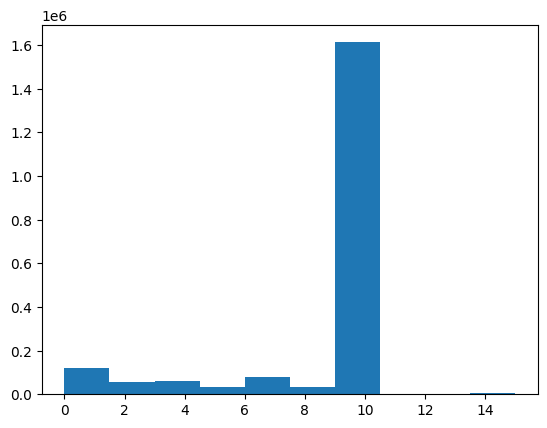

In [18]:
plt.hist(df1["Visibility(mi)"])

In [19]:
import pandas as pd
import re


def classify_weather(x):
    s = str(x).lower().strip()

    # Thunderstorm
    if re.search(r"thunder|t-storm", s):
        return "thunderstorm"

    # Snow
    elif re.search(r"snow|sleet|ice|wintry|freezing|blizzard", s):
        return "snow"

    # Rain
    elif re.search(r"rain|drizzle|shower|precipitation", s):
        return "rain"

    # Fog
    elif re.search(r"fog|mist|haze", s):
        return "fog"

    # Windy
    elif re.search(r"windy|squalls|blowing|sandstorm|dust", s):
        return "windy"

    # Clear
    elif re.search(r"clear|fair", s):
        return "clear"

    # Remaining cloud conditions
    else:
        return "cloudy"

# Apply classification
df1["Weather_Conditions"] = df1["Weather_Conditions"].apply(classify_weather)

# Save output


In [20]:
df1['Weather_Conditions'].value_counts()

Weather_Conditions
cloudy          895015
clear           764374
snow            145179
rain            107277
fog              38953
windy            26035
thunderstorm     23167
Name: count, dtype: int64

In [21]:
df1.drop(columns=["Temperature(F)"],inplace=True)

In [22]:
df1.isna().sum()

Severity                               0
Start_Lat                              0
Start_Lng                              0
StartTime                           1823
EndTime                             1823
Distance(mi)                           0
DelayFromTypicalTraffic(mins)          0
Congestion_Speed                       0
Street                                98
City                                 118
County                                 0
State                                  0
Humidity(%)                        46167
Visibility(mi)                         0
Weather_Event                    1871992
Weather_Conditions                     0
Temperature(C)                     43957
dtype: int64

In [23]:
df1[['Temperature(C)','Humidity(%)']].skew()

Temperature(C)   -0.496969
Humidity(%)      -0.256519
dtype: float64

In [24]:
df1["Temperature(C)"]=df1["Temperature(C)"].fillna(df1["Temperature(C)"].mean())
df1['Humidity(%)']=df1['Humidity(%)'].fillna(df1['Humidity(%)'].mean())

In [25]:
df1['StartTime']=pd.to_datetime(df['StartTime'],utc=True)
df1["Start_hour"]=df1['StartTime'].dt.hour
df1["Start_minute"]=df1['StartTime'].dt.minute
df1["Start_day"]=df1['StartTime'].dt.day
df1["Start_month"]=df1['StartTime'].dt.month


In [26]:
df1['Start_hour']=df1['Start_hour'].fillna(df1['Start_hour'].median())
df1['Start_minute']=df1['Start_minute'].fillna(df1['Start_minute'].median())
df1['Start_month']=df1['Start_month'].fillna(df1['Start_month'].median())
df1['Start_day']=df1['Start_day'].fillna(df1['Start_day'].median())

In [27]:
df2=df1.copy()

In [28]:
df2

,Severity,Start_Lat,Start_Lng,StartTime,EndTime,Distance(mi),DelayFromTypicalTraffic(mins),Congestion_Speed,Street,City,...,State,Humidity(%),Visibility(mi),Weather_Event,Weather_Conditions,Temperature(C),Start_hour,Start_minute,Start_day,Start_month
0,2,39.191032,-120.819740,2016-12-21 00:19:00+00:00,2016-12-20T19:33:47.000-05:00,1.40,2.58,Moderate,I-80 W,Dutch Flat,...,CA,30.0,10.0,NaN,clear,12.222222,0.0,19.0,21.0,12.0
1,0,41.736015,-87.721565,2018-11-16 22:18:00+00:00,2018-11-16T18:08:28.000-05:00,0.73,0.42,Slow,S Pulaski Rd,Chicago,...,IL,70.0,10.0,NaN,cloudy,3.888889,22.0,18.0,16.0,11.0
2,0,32.519043,-93.741096,2021-02-19 01:32:00+00:00,2021-02-18T21:21:32.000-05:00,1.80,1.00,Moderate,E Texas St,Bossier City,...,LA,79.0,10.0,NaN,clear,-1.111111,1.0,32.0,19.0,2.0
3,0,40.730564,-74.001709,2020-11-13 13:06:00+00:00,2020-11-13T08:48:22.000-05:00,1.42,1.00,Slow,Avenue of the Americas,New York,...,NY,93.0,1.0,NaN,rain,8.888889,13.0,6.0,13.0,11.0
4,1,33.758331,-118.238533,2017-08-24 13:54:00+00:00,2017-08-24T11:13:19.000-04:00,2.60,4.90,Slow,W Ocean Blvd,Long Beach,...,CA,79.0,9.0,NaN,cloudy,19.388889,13.0,54.0,24.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,2,36.987309,-121.487808,2019-06-28 22:00:00+00:00,2019-06-28T19:01:26.000-04:00,7.02,12.00,Moderate,Pacheco Pass Hwy,Gilroy,...,CA,38.0,10.0,NaN,clear,23.888889,22.0,0.0,28.0,6.0
1999996,2,34.051392,-118.260674,2018-10-19 20:37:00+00:00,2018-10-19T17:58:47.000-04:00,5.53,2.30,Moderate,CA-110 S,Los Angeles,...,CA,16.0,10.0,NaN,clear,31.111111,20.0,37.0,19.0,10.0
1999997,1,41.944290,-70.981705,2019-11-12 04:21:00+00:00,2019-11-12T00:04:15.000-05:00,1.01,32.00,Slow,South St,Bridgewater,...,MA,77.0,10.0,NaN,cloudy,10.555556,4.0,21.0,12.0,11.0
1999998,2,37.968166,-121.971741,2018-02-02 14:06:00+00:00,2018-02-02T09:46:43.000-05:00,1.64,15.65,Slow,Concord Blvd,Concord,...,CA,80.0,10.0,NaN,clear,8.888889,14.0,6.0,2.0,2.0


In [29]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 21 columns):
 #   Column                         Dtype              
---  ------                         -----              
 0   Severity                       int64              
 1   Start_Lat                      float64            
 2   Start_Lng                      float64            
 3   StartTime                      datetime64[ns, UTC]
 4   EndTime                        object             
 5   Distance(mi)                   float64            
 6   DelayFromTypicalTraffic(mins)  float64            
 7   Congestion_Speed               object             
 8   Street                         object             
 9   City                           object             
 10  County                         object             
 11  State                          object             
 12  Humidity(%)                    float64            
 13  Visibility(mi)                 float64    

In [30]:
df2.isna().sum()

Severity                               0
Start_Lat                              0
Start_Lng                              0
StartTime                           1823
EndTime                             1823
Distance(mi)                           0
DelayFromTypicalTraffic(mins)          0
Congestion_Speed                       0
Street                                98
City                                 118
County                                 0
State                                  0
Humidity(%)                            0
Visibility(mi)                         0
Weather_Event                    1871992
Weather_Conditions                     0
Temperature(C)                         0
Start_hour                             0
Start_minute                           0
Start_day                              0
Start_month                            0
dtype: int64

In [31]:
df2["Severity"]=np.where(df2["Severity"]==4,3,df2["Severity"])

In [32]:
df2.to_csv('data_cleaned.csv',index=False)

In [33]:
df2

,Severity,Start_Lat,Start_Lng,StartTime,EndTime,Distance(mi),DelayFromTypicalTraffic(mins),Congestion_Speed,Street,City,...,State,Humidity(%),Visibility(mi),Weather_Event,Weather_Conditions,Temperature(C),Start_hour,Start_minute,Start_day,Start_month
0,2,39.191032,-120.819740,2016-12-21 00:19:00+00:00,2016-12-20T19:33:47.000-05:00,1.40,2.58,Moderate,I-80 W,Dutch Flat,...,CA,30.0,10.0,NaN,clear,12.222222,0.0,19.0,21.0,12.0
1,0,41.736015,-87.721565,2018-11-16 22:18:00+00:00,2018-11-16T18:08:28.000-05:00,0.73,0.42,Slow,S Pulaski Rd,Chicago,...,IL,70.0,10.0,NaN,cloudy,3.888889,22.0,18.0,16.0,11.0
2,0,32.519043,-93.741096,2021-02-19 01:32:00+00:00,2021-02-18T21:21:32.000-05:00,1.80,1.00,Moderate,E Texas St,Bossier City,...,LA,79.0,10.0,NaN,clear,-1.111111,1.0,32.0,19.0,2.0
3,0,40.730564,-74.001709,2020-11-13 13:06:00+00:00,2020-11-13T08:48:22.000-05:00,1.42,1.00,Slow,Avenue of the Americas,New York,...,NY,93.0,1.0,NaN,rain,8.888889,13.0,6.0,13.0,11.0
4,1,33.758331,-118.238533,2017-08-24 13:54:00+00:00,2017-08-24T11:13:19.000-04:00,2.60,4.90,Slow,W Ocean Blvd,Long Beach,...,CA,79.0,9.0,NaN,cloudy,19.388889,13.0,54.0,24.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,2,36.987309,-121.487808,2019-06-28 22:00:00+00:00,2019-06-28T19:01:26.000-04:00,7.02,12.00,Moderate,Pacheco Pass Hwy,Gilroy,...,CA,38.0,10.0,NaN,clear,23.888889,22.0,0.0,28.0,6.0
1999996,2,34.051392,-118.260674,2018-10-19 20:37:00+00:00,2018-10-19T17:58:47.000-04:00,5.53,2.30,Moderate,CA-110 S,Los Angeles,...,CA,16.0,10.0,NaN,clear,31.111111,20.0,37.0,19.0,10.0
1999997,1,41.944290,-70.981705,2019-11-12 04:21:00+00:00,2019-11-12T00:04:15.000-05:00,1.01,32.00,Slow,South St,Bridgewater,...,MA,77.0,10.0,NaN,cloudy,10.555556,4.0,21.0,12.0,11.0
1999998,2,37.968166,-121.971741,2018-02-02 14:06:00+00:00,2018-02-02T09:46:43.000-05:00,1.64,15.65,Slow,Concord Blvd,Concord,...,CA,80.0,10.0,NaN,clear,8.888889,14.0,6.0,2.0,2.0


In [34]:
x_train,x_test=train_test_split(df2[['Severity','Start_Lat', 'Start_Lng','Humidity(%)', 'Visibility(mi)',
       'Weather_Conditions', 'Temperature(C)', 'Start_hour', 'Start_minute','Start_month', 'Start_day']],test_size=0.3,random_state=42)

In [35]:
x_test

,Severity,Start_Lat,Start_Lng,Humidity(%),Visibility(mi),Weather_Conditions,Temperature(C),Start_hour,Start_minute,Start_month,Start_day
1828401,1,39.951141,-74.953453,28.0,10.0,clear,-1.111111,21.0,48.0,1.0,3.0
1200071,1,45.164093,-123.205116,23.0,10.0,clear,31.111111,23.0,47.0,7.0,17.0
194849,1,42.973923,-71.475998,33.0,10.0,cloudy,7.777778,17.0,58.0,3.0,23.0
1629054,1,38.995621,-76.931908,94.0,1.0,cloudy,14.444444,18.0,48.0,10.0,29.0
191144,1,35.834461,-89.918449,52.0,10.0,cloudy,32.000000,20.0,21.0,9.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...
1573340,1,41.922474,-87.678062,63.0,10.0,cloudy,20.000000,22.0,52.0,4.0,12.0
1963164,2,34.479626,-119.290733,72.0,10.0,cloudy,16.722222,22.0,36.0,5.0,11.0
1771309,0,40.733650,-73.680054,76.0,10.0,cloudy,5.000000,19.0,4.0,2.0,5.0
794110,0,40.742672,-73.659676,73.0,10.0,cloudy,18.333333,13.0,49.0,10.0,10.0


In [36]:
ohe=OneHotEncoder()
temp=ohe.fit_transform(x_train[["Weather_Conditions"]]).toarray()
temp_df=pd.DataFrame(temp,columns=ohe.get_feature_names_out(),index=x_train.index)
ohe2=OneHotEncoder()
temp=ohe2.fit_transform(x_train[["Severity"]]).toarray()
temp_df2=pd.DataFrame(temp,columns=ohe2.get_feature_names_out(),index=x_train.index)

In [37]:
x_train=pd.concat([x_train,temp_df,temp_df2],axis=1)

In [38]:
temp1=ohe.transform(x_test[["Weather_Conditions"]]).toarray()
temp_df1=pd.DataFrame(temp1,columns=ohe.get_feature_names_out(),index=x_test.index)
temp1=ohe2.transform(x_test[["Severity"]]).toarray()
temp_df3=pd.DataFrame(temp1,columns=ohe2.get_feature_names_out(),index=x_test.index)

In [39]:
x_test=pd.concat([x_test,temp_df1,temp_df3],axis=1)

In [40]:
x_train.drop(columns=["Weather_Conditions","Severity"],inplace=True)
x_test.drop(columns=["Weather_Conditions","Severity"],inplace=True)

In [41]:
y_train1,y_test1=train_test_split(df2[['Congestion_Speed']],random_state=42,test_size=0.3)


In [42]:
y_train1["Congestion_Speed"]=y_train1["Congestion_Speed"].map({'Fast':2,'Moderate':1,'Slow':0})

In [43]:
y_test1["Congestion_Speed"]=y_test1["Congestion_Speed"].map({'Fast':2,'Moderate':1,'Slow':0})

In [44]:
y_train1

,Congestion_Speed
1818077,2
919504,0
1816073,0
1189484,0
1346333,2
...,...
259178,1
1414414,1
131932,1
671155,2


In [45]:
x_test.columns

Index(['Start_Lat', 'Start_Lng', 'Humidity(%)', 'Visibility(mi)',
       'Temperature(C)', 'Start_hour', 'Start_minute', 'Start_month',
       'Start_day', 'Weather_Conditions_clear', 'Weather_Conditions_cloudy',
       'Weather_Conditions_fog', 'Weather_Conditions_rain',
       'Weather_Conditions_snow', 'Weather_Conditions_thunderstorm',
       'Weather_Conditions_windy', 'Severity_0', 'Severity_1', 'Severity_2',
       'Severity_3'],
      dtype='object')

In [46]:
x_test.isna().sum()

Start_Lat                          0
Start_Lng                          0
Humidity(%)                        0
Visibility(mi)                     0
Temperature(C)                     0
Start_hour                         0
Start_minute                       0
Start_month                        0
Start_day                          0
Weather_Conditions_clear           0
Weather_Conditions_cloudy          0
Weather_Conditions_fog             0
Weather_Conditions_rain            0
Weather_Conditions_snow            0
Weather_Conditions_thunderstorm    0
Weather_Conditions_windy           0
Severity_0                         0
Severity_1                         0
Severity_2                         0
Severity_3                         0
dtype: int64

In [47]:
x_train.columns

Index(['Start_Lat', 'Start_Lng', 'Humidity(%)', 'Visibility(mi)',
       'Temperature(C)', 'Start_hour', 'Start_minute', 'Start_month',
       'Start_day', 'Weather_Conditions_clear', 'Weather_Conditions_cloudy',
       'Weather_Conditions_fog', 'Weather_Conditions_rain',
       'Weather_Conditions_snow', 'Weather_Conditions_thunderstorm',
       'Weather_Conditions_windy', 'Severity_0', 'Severity_1', 'Severity_2',
       'Severity_3'],
      dtype='object')

In [48]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
x_train[['Start_Lat', 'Start_Lng', 'Humidity(%)', 'Visibility(mi)',
       'Temperature(C)', 'Start_hour', 'Start_minute', 'Start_month',
       'Start_day']]=mms.fit_transform(x_train[['Start_Lat', 'Start_Lng', 'Humidity(%)', 'Visibility(mi)',
       'Temperature(C)', 'Start_hour', 'Start_minute', 'Start_month',
       'Start_day']])

In [49]:
x_test[['Start_Lat', 'Start_Lng', 'Humidity(%)', 'Visibility(mi)',
       'Temperature(C)', 'Start_hour', 'Start_minute', 'Start_month',
       'Start_day']]=mms.transform(x_test[['Start_Lat', 'Start_Lng', 'Humidity(%)', 'Visibility(mi)',
       'Temperature(C)', 'Start_hour', 'Start_minute', 'Start_month',
       'Start_day']])

In [50]:
x_test

,Start_Lat,Start_Lng,Humidity(%),Visibility(mi),Temperature(C),Start_hour,Start_minute,Start_month,Start_day,Weather_Conditions_clear,Weather_Conditions_cloudy,Weather_Conditions_fog,Weather_Conditions_rain,Weather_Conditions_snow,Weather_Conditions_thunderstorm,Weather_Conditions_windy,Severity_0,Severity_1,Severity_2,Severity_3
1828401,0.629835,0.862816,0.272727,0.666667,0.424744,0.913043,0.813559,0.000000,0.066667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1200071,0.843028,0.022512,0.222222,0.666667,0.653270,1.000000,0.796610,0.545455,0.533333,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
194849,0.753457,0.923376,0.323232,0.666667,0.487786,0.739130,0.983051,0.181818,0.733333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1629054,0.590758,0.828361,0.939394,0.066667,0.535067,0.782609,0.813559,0.818182,0.933333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
191144,0.461477,0.602201,0.515152,0.666667,0.659574,0.869565,0.355932,0.727273,0.666667,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573340,0.710456,0.641217,0.626263,0.666667,0.574468,0.956522,0.881356,0.272727,0.366667,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1963164,0.406068,0.090682,0.717172,0.666667,0.551221,0.956522,0.610169,0.363636,0.333333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1771309,0.661837,0.884993,0.757576,0.666667,0.468085,0.826087,0.067797,0.090909,0.133333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
794110,0.662206,0.885347,0.727273,0.666667,0.562648,0.565217,0.830508,0.818182,0.300000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
y_train_target = np.array(y_train1).ravel()
y_test_target = np.array(y_test1).ravel()

# Sample weights
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_target
)
xgb_model = XGBClassifier(
    tree_method="hist",
    device="cuda",
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=8,
    eval_metric="mlogloss",
    random_state=42
)


xgb_model.fit(x_train,y_train_target,sample_weight=sample_weights)
y_pred=xgb_model.predict(x_test) 
print(confusion_matrix(y_pred=y_pred,y_true=y_test1))
print(classification_report(y_pred=y_pred,y_true=y_test1))

d:\ML project\US traffic\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [21:06:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[[ 75991  34683  35187]
 [ 54563 111147  73596]
 [ 23594  30223 161016]]
              precision    recall  f1-score   support

           0       0.49      0.52      0.51    145861
           1       0.63      0.46      0.54    239306
           2       0.60      0.75      0.66    214833

    accuracy                           0.58    600000
   macro avg       0.57      0.58      0.57    600000
weighted avg       0.59      0.58      0.57    600000



In [54]:
xgb_model.get_params()

{'objective': 'multi:softprob',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': 'cuda',
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'mlogloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.02,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 8,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 1000,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': 'hist',
 'validate_parameters': None,
 'verbosity': None}

In [1]:
import requests

url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 13.08,      # Chennai
    "longitude": 80.27,
    "hourly": "temperature_2m",
    "start_date": "2026-05-23",
    "end_date": "2026-05-23"
}

response = requests.get(url, params=params)
data = response.json()

target_time = "2026-05-23T15:00"

times = data["hourly"]["time"]
temps = data["hourly"]["temperature_2m"]

if target_time in times:
    i = times.index(target_time)
    print("Date:", target_time)
    print("Temperature:", temps[i], "°C")
else:
    print("Data not available")

Date: 2026-05-23T15:00
Temperature: 31.8 °C


In [ ]:
import requests

# Convert weather code → limited categories
def get_weather_condition(code, wind_speed):

    if code in [95, 96, 99]:
        return "Thunderstorm"

    elif code in [71, 73, 75, 77, 85, 86]:
        return "Snow"

    elif code in [45, 48]:
        return "Fog"

    elif code in [51, 53, 55, 61, 63, 65, 80, 81, 82]:
        return "Rain"

    elif wind_speed > 30:
        return "Windy"

    elif code in [1, 2, 3]:
        return "Cloudy"

    else:
        return "Clear"


url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 13.08,   # Chennai
    "longitude": 80.27,

    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "visibility",
        "weather_code",
        "wind_speed_10m"
    ],

    "start_date": "2026-05-23",
    "end_date": "2026-05-23"
}

response = requests.get(url, params=params)

data = response.json()

target_time = "2026-05-23T15:00"

times = data["hourly"]["time"]

if target_time in times:

    i = times.index(target_time)

    temp = data["hourly"]["temperature_2m"][i]

    humidity = data["hourly"]["relative_humidity_2m"][i]

    visibility = data["hourly"]["visibility"][i]

    weather_code = data["hourly"]["weather_code"][i]

    wind = data["hourly"]["wind_speed_10m"][i]

    condition = get_weather_condition(
        weather_code,
        wind
    )

    print("Temperature:", temp, "°C")
    print("Humidity:", humidity, "%")
    print("Visibility:",round(visibility / 1609.34, 2),"miles")
    print("Weather Condition:", condition)

else:
    print("No data found")

Temperature: 31.8 °C
Humidity: 55 %
Visibility: 13.92 miles
Weather Condition: Cloudy


In [5]:
from src.utils.common import load_obj

ModuleNotFoundError: No module named 'src'